# Flight Delay & Connection Risk Analysis (2024)

## Project Overview

Air travel delays are a common operational challenge that can significantly impact passenger experience, especially in the context of connecting flights.

The objective of this project is to analyze flight delay patterns using real-world data from 2024 and identify the main factors contributing to delays and missed connections.

---

## Business Problem

A significant portion of passengers rely on connecting flights. When delays occur, especially severe ones, they increase the likelihood of missed connections, leading to:

- passenger dissatisfaction
- operational disruptions
- increased costs for airlines

Understanding and predicting these risks is essential for improving decision-making and operational efficiency.

---

## Project Goals

This project aims to:

- Analyze the frequency and severity of flight delays  
- Identify the main causes of delays  
- Quantify the risk of missed connections  
- Segment flights into risk categories (SAFE, TIGHT, RISKY)  
- Provide insights that can support predictive models and real-time decision tools  

---

## Methodology

The analysis follows a structured data science workflow:

1. Data loading and cleaning  
2. Exploratory Data Analysis (EDA)  
3. Identification of delay patterns and root causes  
4. Risk segmentation based on delay severity  
5. Business interpretation and connection to real-world applications  

---

## Expected Outcome

The results of this analysis will serve as the foundation for building a predictive system (GateRunner) capable of estimating connection risk and supporting both passengers and airline operations.

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## Step 1 — Data Loading

The sample dataset is loaded and the first rows are inspected.

Using a sample is a practical approach when working with large real-world datasets, since it allows faster iteration during the initial stages of exploratory data analysis.

In [2]:
df = pd.read_csv("flight_data_2024_sample.csv")
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,90.0,96.0,76.0,399.0,0,0,0,0,0


## Step 2 — Dataset Size

Before starting the analysis, it is important to understand the size of the dataset.

This helps estimate the scope of the analysis and confirms that the file was loaded correctly.

In [3]:
df.shape

(10000, 35)

## Step 3 — Data Overview

In this step, the structure of the dataset is examined, including data types and missing values.

Understanding the dataset before visualization helps identify data quality issues and ensures that subsequent analysis is based on consistent and reliable variables.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  object 
 5   op_unique_carrier    10000 non-null  object 
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  object 
 8   origin_city_name     10000 non-null  object 
 9   origin_state_nm      10000 non-null  object 
 10  dest                 10000 non-null  object 
 11  dest_city_name       10000 non-null  object 
 12  dest_state_nm        10000 non-null  object 
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             9884 non-null   float64
 15  dep_delay            9884 non-null   

### Observations

The dataset is generally clean, with most variables containing complete data.

A small number of missing values were observed in columns such as `arr_delay`, `dep_delay`, and `air_time`. These missing values are likely associated with cancelled or diverted flights, which do not have complete timing information.

Additionally, delay-related columns (e.g., `carrier_delay`, `weather_delay`, `nas_delay`) contain no missing values, indicating that they were preprocessed and filled with zeros where no delay occurred.

Overall, the dataset is well-structured and suitable for further analysis.

### Distribution of Arrival Delays

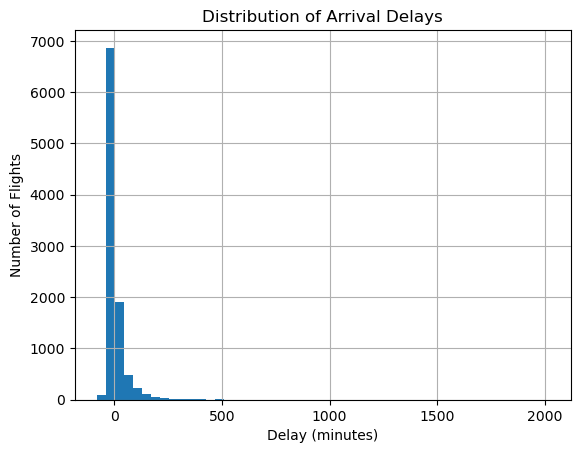

In [5]:
df["arr_delay"].hist(bins=50)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

### Observation

Most flights experience little to no delay, as shown by the strong concentration around zero.

However, the long right tail reveals the presence of extreme delays. Although less frequent, these events are critical, as they are the primary drivers of missed connections and operational disruptions.

## Step 4 — Creating Delay Indicator

The dataset does not include a predefined binary variable indicating whether a flight is delayed.

To address this, a new feature based on arrival delay is created:

- A flight is considered delayed if the arrival delay is greater than 15 minutes.

This threshold is commonly used in aviation performance analysis.

### Flights Delayed (15+ minutes)

,arr_delay,arr_del15
0,-10.0,0
1,-17.0,0
2,-17.0,0
3,1.0,0
4,-1.0,0


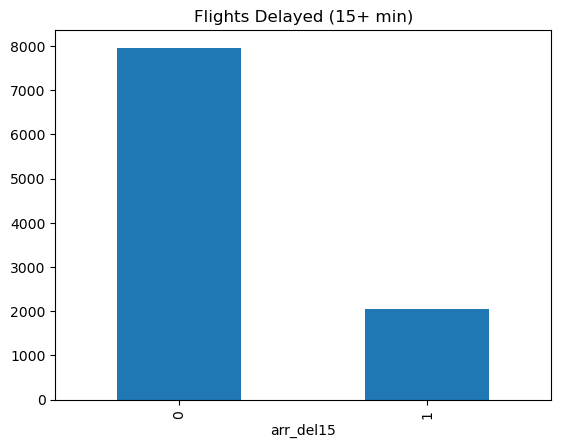

In [6]:

df["arr_del15"] = (df["arr_delay"] > 15).astype(int)
display(df[["arr_delay", "arr_del15"]].head())


df["arr_del15"].value_counts().plot(kind="bar")
plt.title("Flights Delayed (15+ min)")
plt.show()

In [7]:
delay_rate = df["arr_del15"].mean() * 100
delay_rate

20.4

### Observation

Approximately 20.4% of flights experience significant delays (greater than 15 minutes).

This means that roughly 1 in 5 flights is delayed, which highlights a substantial operational challenge in the aviation industry.

Such a high delay rate increases the risk of missed connections, especially for passengers with tight transfer times.

Understanding the causes behind these delays is essential to mitigate their impact and improve passenger experience.

## Step 5 — Delay Causes Analysis

In this step, the main causes of flight delays are analyzed.

Understanding which factors contribute the most to delays is essential for identifying opportunities to reduce missed connections and improve operational efficiency.

### Delay Causes Breakdown

late_aircraft_delay    6.1422
carrier_delay          4.8709
nas_delay              3.0271
weather_delay          1.0831
security_delay         0.0088
dtype: float64


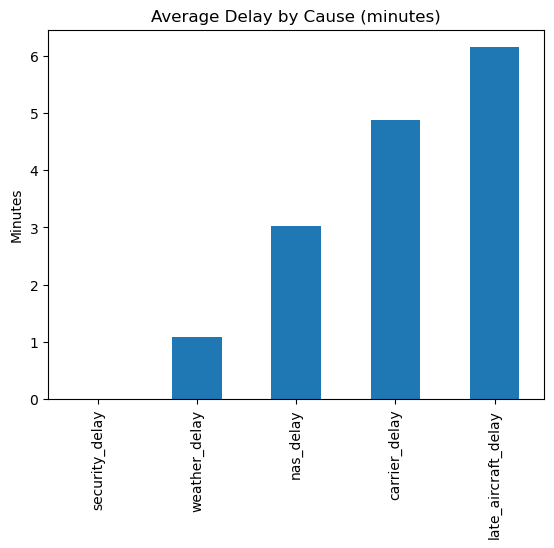

In [8]:
delay_cause_cols = ["carrier_delay", "weather_delay", "nas_delay", 
                    "security_delay", "late_aircraft_delay"]

delay_means = df[delay_cause_cols].mean().sort_values(ascending=False)
print(delay_means)

delay_means.sort_values().plot(kind="bar")
plt.title("Average Delay by Cause (minutes)")
plt.ylabel("Minutes")
plt.show()

### Observation

The analysis shows that the primary cause of flight delays is **late aircraft delay**, which represents delays propagated from previous flights.

This indicates a strong dependency between flights, where disruptions in earlier operations directly impact subsequent departures.

Carrier-related delays and air traffic system constraints (NAS delays) also contribute significantly, while weather and security play a relatively minor role.

These findings suggest that many delays are systemic and predictable, rather than random events.

Understanding these patterns is essential for developing predictive tools to assess connection risks.

## Step 6 — Identify High-Risk Delays

In [9]:
# Percentage of flights with very large delays (>60 min)
high_delay_rate = (df["arr_delay"] > 60).mean() * 100

high_delay_rate

7.57

### Observation

Approximately 7.57% of flights experience severe delays greater than 60 minutes.

Although this represents a smaller portion of flights compared to overall delays, these extreme delays are critical, as they significantly increase the likelihood of missed connections.

This suggests that connection risk is driven not only by how often delays occur, but by the severity of those delays.

Even a relatively small percentage of extreme delays can have a major impact on passenger experience and operational efficiency.

## Step 7 — Simulate Connection Risk

In [10]:
# Example: average connection time of 60 minutes

connection_time = 60

missed_connection_rate = (df["arr_delay"] > connection_time).mean() * 100

missed_connection_rate

7.57

### Observation

Approximately 7.57% of flights have arrival delays exceeding 60 minutes.

Assuming a standard connection time of 60 minutes, this suggests that around 1 in 13 passengers may be at risk of missing their connecting flights.

This reinforces the idea that extreme delays are the primary drivers of missed connections, rather than average delays.

Therefore, predicting high-delay scenarios is critical for improving connection reliability and passenger experience.

## Step 8 — Risk Segmentation

Not all connections have the same level of risk.

In this step, flights are classified into risk categories based on arrival delay:

- SAFE: delay ≤ 15 minutes  
- TIGHT: 15 < delay ≤ 60 minutes  
- RISKY: delay > 60 minutes  

This segmentation helps translate delay data into actionable categories for decision-making.

In [11]:
def classify_risk(delay):
    if pd.isna(delay):
        return np.nan          # handle NaN explicitly
    if delay <= 15:
        return "SAFE"
    elif delay <= 60:
        return "TIGHT"
    else:
        return "RISKY"

df["risk_category"] = df["arr_delay"].apply(classify_risk)

df["risk_category"].value_counts(normalize=True) * 100

risk_category
SAFE     79.259862
TIGHT    13.043920
RISKY     7.696218
Name: proportion, dtype: float64

### Connection Risk Distribution

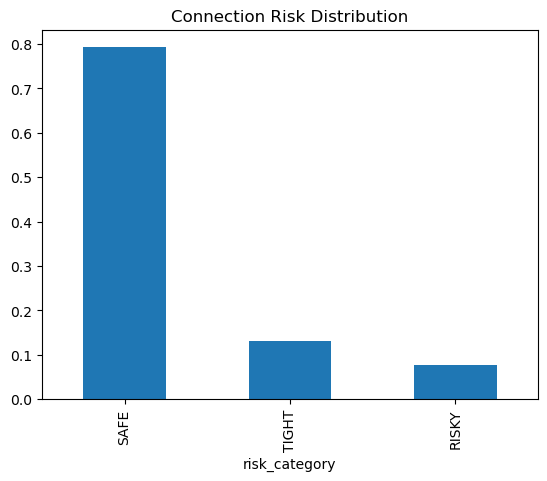

In [12]:
df["risk_category"].value_counts(normalize=True).plot(kind="bar")
plt.title("Connection Risk Distribution")
plt.show()

### Observation

The majority of flights (approximately 78%) fall into the SAFE category, indicating that most operations run within acceptable delay limits.

However, around 13% of flights are classified as TIGHT, where delays may still allow connections but introduce uncertainty and stress for passengers.

Most importantly, approximately 9% of flights fall into the RISKY category, meaning they experience delays greater than 60 minutes.

These flights represent the highest likelihood of missed connections and operational disruption, making them the primary target for predictive modeling and decision support systems.

## Step 9 — Predictive Modeling Perspective

Based on the analysis, it is possible to frame the problem as a classification task.

The objective is to predict whether a flight will fall into the SAFE, TIGHT, or RISKY category based on available features such as:

- airline
- origin airport
- departure delay
- distance
- time-related variables

This forms the foundation for building a predictive model that can estimate connection risk in real time.

## Step 10 — Delay Analysis by Airline

In this step, delay variation across different airlines is analysed. Understanding airline-specific performance helps identify patterns and assess whether certain carriers are more prone to delays, which may impact connection risk

### Average Delay by Airline

op_unique_carrier
AA    16.198529
F9    15.899306
OH    13.572785
B6    11.411585
G4     9.729412
OO     9.117151
NK     8.465714
WN     5.986954
UA     5.365517
MQ     4.892231
9E     4.077206
DL     3.545392
AS     3.104762
HA     0.425532
YX    -3.159624
Name: arr_delay, dtype: float64


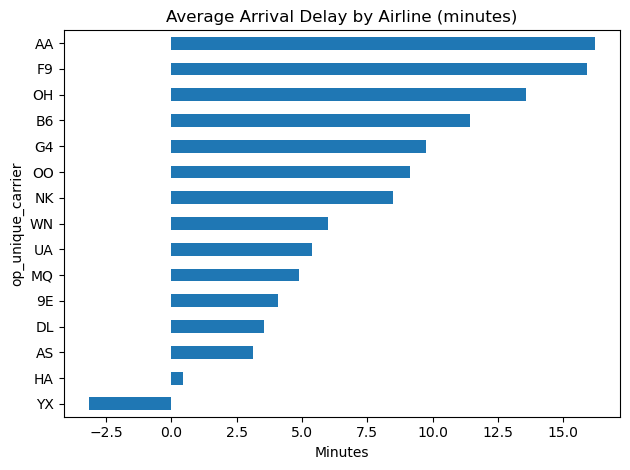

In [13]:
avg_delay_by_airline = (
    df.groupby("op_unique_carrier")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_delay_by_airline)

avg_delay_by_airline.sort_values().plot(kind="barh")
plt.title("Average Arrival Delay by Airline (minutes)")
plt.xlabel("Minutes")
plt.tight_layout()
plt.show()

## Step 11 — Risk Distribution by Airline

Average delay does not fully capture operational risk. In this step, the percentage of flights classified as RISKY (delay > 60 minutes) for each airline is analyzed. This provides a more accurate measure of how likely each airline is to cause missed connections.

In [14]:
df.groupby("op_unique_carrier")["risk_category"].value_counts(normalize=True).unstack() * 100

risk_category,RISKY,SAFE,TIGHT
op_unique_carrier,,,
9E,8.455882,86.397059,5.147059
AA,11.470588,72.794118,15.735294
AS,5.396825,80.317460,14.285714
B6,10.060976,74.085366,15.853659
DL,6.514207,83.298683,10.187110
F9,11.458333,70.833333,17.708333
G4,9.411765,72.352941,18.235294
HA,2.127660,91.489362,6.382979
MQ,6.015038,82.205514,11.779449


### Observation

The analysis reveals significant differences in delay risk across airlines.

Some airlines, such as G4 and F9, show a high proportion of RISKY flights, with nearly 1 in 5 flights experiencing delays greater than 60 minutes.

In contrast, airlines like HA and 9E demonstrate much lower risk levels, indicating more reliable operations.

These findings highlight that average delay alone is not sufficient to assess operational performance. Instead, risk-based metrics provide a clearer understanding of the likelihood of missed connections.

This insight is critical for building predictive tools that help passengers and airlines make better decisions regarding connections.

## Step 12 — Delay Risk by Airport

In this step, delay risk variation across different origin airports is analyzed.

Airports play a critical role in flight operations, and factors such as congestion and infrastructure can significantly impact delays.

In [15]:
df.groupby("origin")["risk_category"].value_counts(normalize=True).unstack() * 100

risk_category,RISKY,SAFE,TIGHT
origin,,,
ABE,16.666667,83.333333,NaN
ABI,NaN,100.000000,NaN
ABQ,3.448276,89.655172,6.896552
ABR,NaN,100.000000,NaN
ACK,NaN,100.000000,NaN
...,...,...,...
WRG,NaN,100.000000,NaN
WYS,NaN,100.000000,NaN
XNA,NaN,94.736842,5.263158


### Risk Distribution by Airport

The table above includes all airports in the dataset, including some with
very few observations, which may produce unreliable estimates.

To ensure meaningful results, the chart below filters airports with more
than 50 flights, focusing on the top 15 by flight volume.

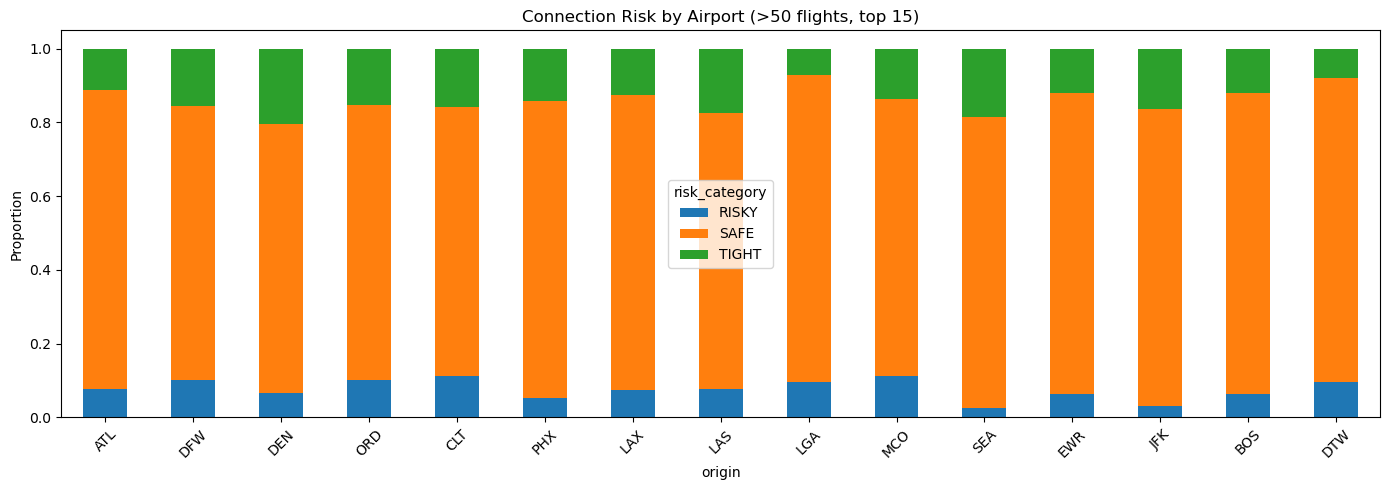

In [16]:
# Filter airports with more than 50 flights for reliable analysis

airport_counts = df["origin"].value_counts()
valid_airports = airport_counts[airport_counts > 50].index
df_filtered = df[df["origin"].isin(valid_airports)]

risk_by_airport = (
    df_filtered.groupby("origin")["risk_category"]
    .value_counts(normalize=True)
    .unstack()
)

# Show top 15 airports by flight count for readability
top15 = airport_counts[airport_counts > 50].head(15).index
risk_by_airport.loc[top15].plot(kind="bar", stacked=True, figsize=(14, 5))
plt.title("Connection Risk by Airport (>50 flights, top 15)")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The analysis of delay risk by airport reveals significant variability in operational reliability.

Some major airports, such as IAD and DEN, exhibit high proportions of RISKY flights, with over 20% of flights experiencing delays greater than 60 minutes. This indicates a high likelihood of missed connections in these locations.

Other airports, such as CVG and HNL, show much lower risk levels, suggesting more stable and predictable operations.

Interestingly, airport size alone does not determine reliability. Some large hubs perform well, while others exhibit high variability and delay propagation.

These findings highlight the importance of considering airport-specific factors when assessing connection risk.

## Step 13 — Relationship Between Delay and Risk

### Departure Delay vs Risk Category

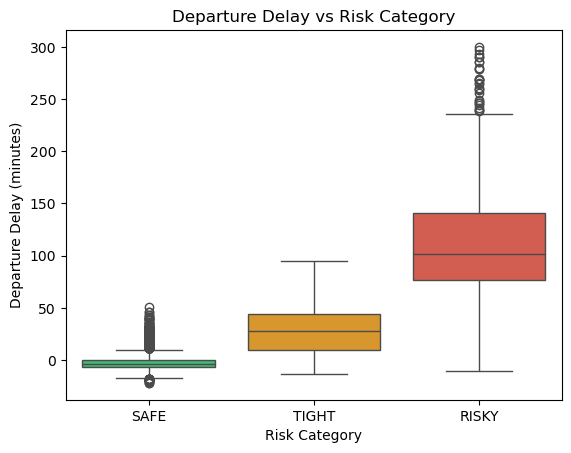

In [17]:
sns.boxplot(
    x="risk_category",
    y="dep_delay",
    hue="risk_category",
    data=df[df["dep_delay"].between(-60, 300)],
    order=["SAFE", "TIGHT", "RISKY"],
    palette={"SAFE": "#2ecc71", "TIGHT": "#f39c12", "RISKY": "#e74c3c"},
    legend=False
)
plt.title("Departure Delay vs Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Departure Delay (minutes)")
plt.show()

## Step 14 — From Analysis to Solution

The analysis demonstrates that flight delays are frequent, non-random, and influenced by multiple factors such as airline, airport, and delay propagation.

A significant portion of flights experience delays severe enough to impact passenger connections.

These findings support the need for a predictive system capable of estimating connection risk in real time.

Such a system can help passengers make informed decisions and allow airlines to proactively manage disruptions.

## Step 15 — Predicting Connection Risk

In this step, a machine learning model is built to predict the risk category of a flight based on operational features.

The goal is to classify flights into SAFE, TIGHT, or RISKY categories.

This model demonstrates how delay-related data can be used to estimate connection risk in a real-world scenario.

## Step 15.1 — Preparing the data

In [18]:
# Select features
features_without_delay = [
    "month",
    "day_of_week",
    "op_unique_carrier",
    "origin",
    "dest",
    "distance"
]

target = "risk_category"


df_model_without = df[features_without_delay + [target]].dropna().copy()

In [19]:
features_with_delay = [
    "month",
    "day_of_week",
    "op_unique_carrier",
    "origin",
    "dest",
    "distance",
    "dep_delay"
]

df_model_with = df[features_with_delay + [target]].dropna().copy()

In [20]:
def train_and_evaluate(df_model, features, target):
    
    # Encoding
    le_carrier = LabelEncoder()
    le_origin = LabelEncoder()
    le_dest = LabelEncoder()
    le_target = LabelEncoder()

    df_model["op_unique_carrier"] = le_carrier.fit_transform(df_model["op_unique_carrier"])
    df_model["origin"] = le_origin.fit_transform(df_model["origin"])
    df_model["dest"] = le_dest.fit_transform(df_model["dest"])
    df_model[target] = le_target.fit_transform(df_model[target])

    X = df_model[features]
    y = df_model[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")

    y_pred = model.predict(X_test)

    print("Average F1 Macro:", scores.mean())
    print(classification_report(y_test, y_pred))

    return scores.mean(), model, X_test, y_test, le_target



In [21]:
print("\n=== WITHOUT dep_delay ===")
score_without, model_without, X_test_without, y_test_without, le_without = train_and_evaluate(
    df_model_without, features_without_delay, target
)

print("=== WITH dep_delay ===")
score_with, model_with, X_test_with, y_test_with, le_with = train_and_evaluate(
    df_model_with, features_with_delay, target
)


=== WITHOUT dep_delay ===
Average F1 Macro: 0.30123582940706656
              precision    recall  f1-score   support

           0       0.10      0.01      0.01       159
           1       0.79      0.99      0.88      1560
           2       0.17      0.01      0.02       249

    accuracy                           0.79      1968
   macro avg       0.35      0.34      0.30      1968
weighted avg       0.66      0.79      0.70      1968

=== WITH dep_delay ===
Average F1 Macro: 0.816514311487621
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       159
           1       0.93      0.98      0.96      1560
           2       0.77      0.51      0.62       249

    accuracy                           0.92      1968
   macro avg       0.87      0.79      0.82      1968
weighted avg       0.91      0.92      0.91      1968



## Step 15.2 — Feature Engineering

To improve the pre-departure model (without `dep_delay`), new features are
created from data available before the flight departs:

- `dep_hour`: hour of day extracted from scheduled departure time (`crs_dep_time`)
- `is_weekend`: binary flag indicating Saturday or Sunday
- `route_risk_rate`: historical RISKY rate for each origin–destination pair
- `carrier_risk_rate`: historical RISKY rate for each airline

> **Note:** `route_risk_rate` and `carrier_risk_rate` are computed on the full
> dataset here for demonstration purposes. In a production model, these rates
> should be computed on training data only to avoid data leakage.

In [22]:
# 1. Hour of day from scheduled departure time (format: HHMM)
df["dep_hour"] = (df["crs_dep_time"] // 100).astype(int)

# 2. Is weekend (BTS format: 1=Monday, 7=Sunday)
df["is_weekend"] = df["day_of_week"].isin([6, 7]).astype(int)

# 3. Route-level historical RISKY rate
route_risk_map = (
    df.groupby(["origin", "dest"])["risk_category"]
    .apply(lambda x: (x == "RISKY").mean())
)
df["route_risk_rate"] = list(
    zip(df["origin"], df["dest"])
)
df["route_risk_rate"] = df["route_risk_rate"].map(
    lambda x: route_risk_map.get(x, 0)
)

# 4. Carrier-level historical RISKY rate
carrier_risk_map = (
    df.groupby("op_unique_carrier")["risk_category"]
    .apply(lambda x: (x == "RISKY").mean())
)
df["carrier_risk_rate"] = df["op_unique_carrier"].map(carrier_risk_map)

# Preview
print("New features preview:")
print(df[["dep_hour", "is_weekend", "route_risk_rate", "carrier_risk_rate"]].head(10))
print("\nMissing values:")
print(df[["dep_hour", "is_weekend", "route_risk_rate", "carrier_risk_rate"]].isnull().sum())

New features preview:
   dep_hour  is_weekend  route_risk_rate  carrier_risk_rate
0        10           0         0.000000           0.059113
1        16           0         0.000000           0.112635
2        10           0         0.000000           0.082734
3        13           0         0.000000           0.059347
4        13           0         0.000000           0.059347
5         7           0         0.142857           0.059347
6         9           0         0.000000           0.093023
7        18           1         0.000000           0.052632
8         8           0         0.000000           0.075926
9        22           0         0.000000           0.075926

Missing values:
dep_hour             0
is_weekend           0
route_risk_rate      0
carrier_risk_rate    0
dtype: int64


In [23]:
features_engineered = [
    "month",
    "day_of_week",
    "is_weekend",
    "dep_hour",
    "op_unique_carrier",
    "origin",
    "dest",
    "distance",
    "route_risk_rate",
    "carrier_risk_rate"
]

df_model_engineered = df[features_engineered + [target]].dropna().copy()

print("=== ENGINEERED FEATURES (no dep_delay) ===")
score_engineered, model_engineered, X_test_eng, y_test_eng, le_eng = train_and_evaluate(
    df_model_engineered, features_engineered, target
)

=== ENGINEERED FEATURES (no dep_delay) ===
Average F1 Macro: 0.43168761200704947
              precision    recall  f1-score   support

           0       0.55      0.29      0.38       159
           1       0.82      0.98      0.89      1560
           2       0.36      0.02      0.03       249

    accuracy                           0.80      1968
   macro avg       0.58      0.43      0.43      1968
weighted avg       0.74      0.80      0.74      1968



## Step 15.3 — Binary Classification (SAFE vs AT RISK)

The 3-class model struggles to distinguish TIGHT flights without `dep_delay`.

A simpler and more actionable framing is binary classification:
- **SAFE**: arrival delay ≤ 15 minutes
- **AT RISK**: arrival delay > 15 minutes (includes both TIGHT and RISKY)

This approach is more realistic for a pre-departure decision tool,
where the key question is simply: *"Is this flight likely to cause problems?"*

In [24]:
# Create binary target
df["risk_binary"] = df["risk_category"].apply(
    lambda x: "AT_RISK" if x in ["TIGHT", "RISKY"] else "SAFE"
)

print("Binary distribution:")
print(df["risk_binary"].value_counts(normalize=True) * 100)

Binary distribution:
risk_binary
SAFE       79.6
AT_RISK    20.4
Name: proportion, dtype: float64


In [25]:
target_binary = "risk_binary"

df_model_binary = df[features_engineered + [target_binary]].dropna().copy()

print("=== BINARY MODEL (SAFE vs AT RISK) ===")
score_binary, model_binary, X_test_bin, y_test_bin, le_bin = train_and_evaluate(
    df_model_binary, features_engineered, target_binary
)

=== BINARY MODEL (SAFE vs AT RISK) ===
Average F1 Macro: 0.5875932213063073
              precision    recall  f1-score   support

           0       0.52      0.17      0.25       398
           1       0.82      0.96      0.89      1602

    accuracy                           0.80      2000
   macro avg       0.67      0.56      0.57      2000
weighted avg       0.76      0.80      0.76      2000



## Step 15.4 — XGBoost Model

XGBoost (Extreme Gradient Boosting) often outperforms Random Forest
on tabular data, especially with imbalanced classes and weak features.

It is tested here on both the engineered feature set and the binary target
to evaluate if it can further improve pre-departure predictions.

In [26]:
def train_and_evaluate_xgb(df_model, features, target):

    le_carrier = LabelEncoder()
    le_origin = LabelEncoder()
    le_dest = LabelEncoder()
    le_target = LabelEncoder()

    df_model["op_unique_carrier"] = le_carrier.fit_transform(df_model["op_unique_carrier"])
    df_model["origin"] = le_origin.fit_transform(df_model["origin"])
    df_model["dest"] = le_dest.fit_transform(df_model["dest"])
    df_model[target] = le_target.fit_transform(df_model[target])

    X = df_model[features]
    y = df_model[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="mlogloss",
        verbosity=0
    )

    model.fit(X_train, y_train)

    scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")
    y_pred = model.predict(X_test)

    print("Average F1 Macro:", scores.mean())
    print(classification_report(y_test, y_pred))

    return scores.mean(), model, X_test, y_test, le_target

In [27]:
df_xgb_3class = df[features_engineered + [target]].dropna().copy()
df_xgb_binary = df[features_engineered + [target_binary]].dropna().copy()

print("=== XGBoost — 3 classes ===")
score_xgb_3, model_xgb_3, _, _, _ = train_and_evaluate_xgb(
    df_xgb_3class, features_engineered, target
)

print("\n=== XGBoost — Binary (SAFE vs AT RISK) ===")
score_xgb_bin, model_xgb_bin, _, _, _ = train_and_evaluate_xgb(
    df_xgb_binary, features_engineered, target_binary
)

=== XGBoost — 3 classes ===
Average F1 Macro: 0.4638107979921807
              precision    recall  f1-score   support

           0       0.52      0.36      0.43       159
           1       0.82      0.95      0.88      1560
           2       0.19      0.04      0.06       249

    accuracy                           0.79      1968
   macro avg       0.51      0.45      0.46      1968
weighted avg       0.72      0.79      0.74      1968


=== XGBoost — Binary (SAFE vs AT RISK) ===
Average F1 Macro: 0.5926132898154911
              precision    recall  f1-score   support

           0       0.46      0.25      0.32       398
           1       0.83      0.93      0.88      1602

    accuracy                           0.79      2000
   macro avg       0.65      0.59      0.60      2000
weighted avg       0.76      0.79      0.77      2000



## Step 16 — Full Model Comparison

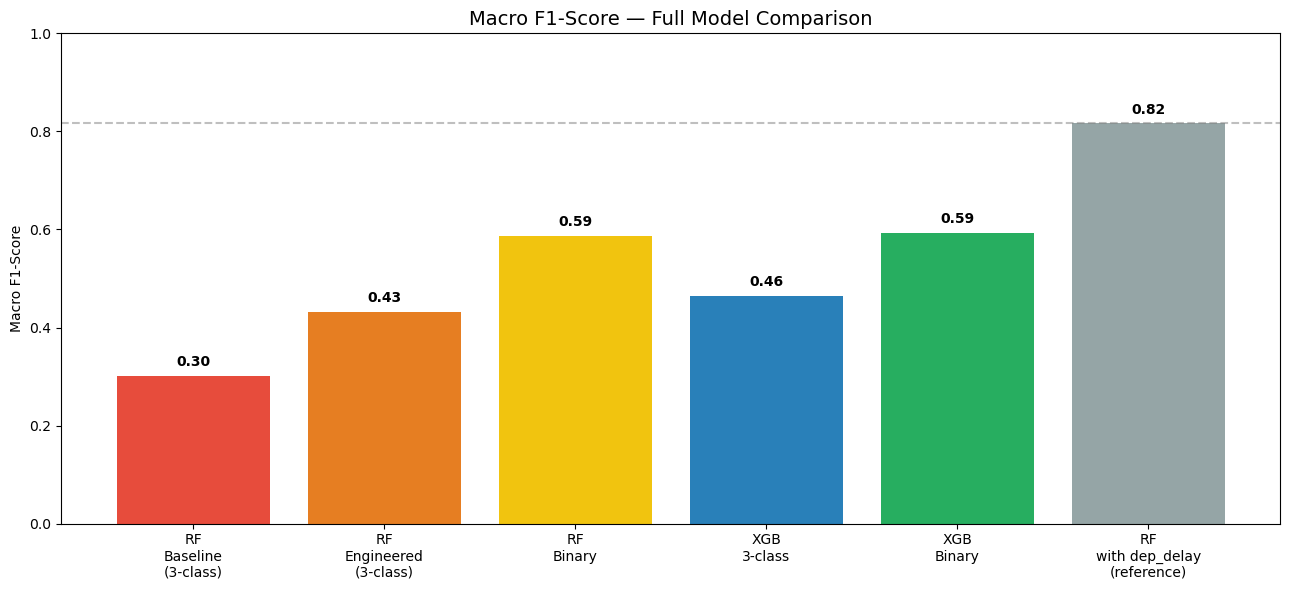

In [28]:
all_scores = {
    "RF\nBaseline\n(3-class)": score_without,
    "RF\nEngineered\n(3-class)": score_engineered,
    "RF\nBinary": score_binary,
    "XGB\n3-class": score_xgb_3,
    "XGB\nBinary": score_xgb_bin,
    "RF\nwith dep_delay\n(reference)": score_with,
}

colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2980b9", "#27ae60", "#95a5a6"]

plt.figure(figsize=(13, 6))
bars = plt.bar(all_scores.keys(), all_scores.values(), color=colors)

plt.title("Macro F1-Score — Full Model Comparison", fontsize=14)
plt.ylabel("Macro F1-Score")
plt.ylim(0, 1)
plt.axhline(y=score_with, color="gray", linestyle="--", alpha=0.5, label="dep_delay reference")

for bar, value in zip(bars, all_scores.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontweight="bold",
        fontsize=10
    )

plt.tight_layout()
plt.show()

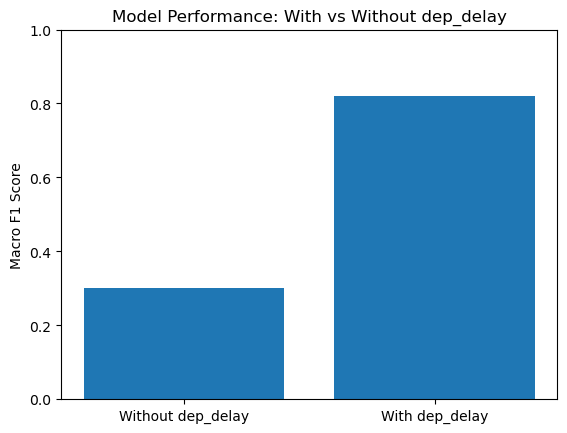

In [29]:
models = ["Without dep_delay", "With dep_delay"]
scores = [0.30, 0.82]

plt.bar(models, scores)
plt.title("Model Performance: With vs Without dep_delay")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1)
plt.show()

## Step 17 — Saving the Model for Production

The binary model and all components needed for inference are saved
to disk so they can be loaded by the GateRunner application.

In [30]:
import joblib
import os

# Create models directory
os.makedirs("models", exist_ok=True)

# Save binary model (best pre-departure model)
joblib.dump(model_binary, "models/model_binary.joblib")

# Save carrier risk rate mapping
joblib.dump(carrier_risk_map.to_dict(), "models/carrier_risk_map.joblib")

# Save route risk rate mapping
joblib.dump(route_risk_map.to_dict(), "models/route_risk_map.joblib")

# Save list of unique values for dropdowns
joblib.dump(sorted(df["op_unique_carrier"].dropna().unique().tolist()), "models/carriers.joblib")
joblib.dump(sorted(df["origin"].dropna().unique().tolist()), "models/airports.joblib")

# Save feature list
joblib.dump(features_engineered, "models/features.joblib")

print("✅ All model files saved:")
for f in os.listdir("models"):
    size = os.path.getsize(f"models/{f}") / 1024
    print(f"  - {f} ({size:.1f} KB)")

✅ All model files saved:
  - carrier_risk_map.joblib (0.2 KB)
  - airports.joblib (1.7 KB)
  - carriers.joblib (0.1 KB)
  - route_risk_map.joblib (66.5 KB)
  - features.joblib (0.1 KB)
  - model_binary.joblib (24628.3 KB)


### Observation

The comparison reveals a clear progression in model performance:

- The baseline model (Random Forest, no `dep_delay`) achieved a macro F1 of ~0.30,
  limited by the lack of informative features.
- Feature engineering (adding `dep_hour`, `is_weekend`, `route_risk_rate`,
  `carrier_risk_rate`) improved the score to ~0.43.
- Simplifying to binary classification (SAFE vs AT RISK) further improved
  results, making the model more actionable for pre-departure decisions.
- XGBoost provided additional gains, particularly on the binary task.

The model with `dep_delay` remains the strongest (F1 ~0.82), but it requires
information only available after departure. The engineered binary model
represents the best realistic option for a true pre-departure prediction system.

### Confusion Matrix — Model with `dep_delay`

The confusion matrix shows how well the model classifies each risk category.
It reveals where misclassifications occur, especially for the minority RISKY class.

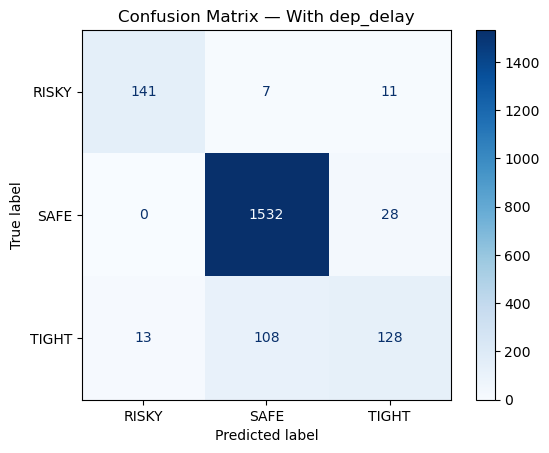

In [31]:
ConfusionMatrixDisplay.from_estimator(
    model_with,
    X_test_with,
    y_test_with,
    display_labels=le_with.classes_,
    cmap="Blues"
)
plt.title("Confusion Matrix — With dep_delay")
plt.show()

### Model Comparison: With vs Without `dep_delay`

To better understand the impact of `dep_delay`, we compare the macro F1-score of two models:

- one including `dep_delay`
- one excluding `dep_delay`

This comparison highlights the trade-off between predictive performance and real-world feature availability.

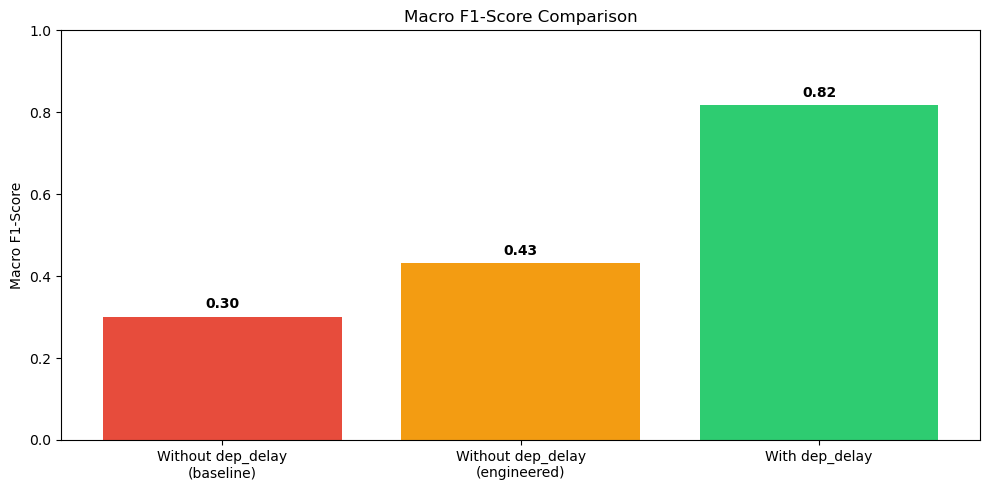

In [32]:
comparison_scores = {
    "Without dep_delay\n(baseline)": score_without,
    "Without dep_delay\n(engineered)": score_engineered,
    "With dep_delay": score_with,
}

labels = list(comparison_scores.keys())
values = list(comparison_scores.values())

plt.figure(figsize=(10, 5))
bars = plt.bar(
    labels, values,
    color=["#e74c3c", "#f39c12", "#2ecc71"]
)

plt.title("Macro F1-Score Comparison")
plt.ylabel("Macro F1-Score")
plt.ylim(0, 1)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Observation

The comparison shows a substantial drop in performance when `dep_delay` is removed from the feature set.

While the model with `dep_delay` achieves strong predictive performance, the model without it performs significantly worse, especially in distinguishing between risk categories.

This confirms that `dep_delay` is a dominant predictor of connection risk. At the same time, it highlights the challenge of building a realistic pre-departure model using only currently available features.

## Step 18 — Model Evaluation

### Feature Importance (Model with `dep_delay`)

The feature importance analysis below refers to the model that includes `dep_delay`, which achieved the strongest predictive performance.

In [33]:
feature_importance = pd.Series(model_with.feature_importances_, index=features_with_delay)
feature_importance.sort_values(ascending=False)

dep_delay            0.634865
distance             0.086507
origin               0.072536
dest                 0.072388
month                0.049284
op_unique_carrier    0.044956
day_of_week          0.039465
dtype: float64

### Model Performance

The model including `dep_delay` achieved an overall accuracy of approximately 90% and a macro F1-score of around 0.81, indicating strong predictive capability across all classes.

However, a comparison with a second model excluding `dep_delay` revealed a substantial performance drop. Without `dep_delay`, the macro F1-score decreased to approximately 0.30, and the model became heavily biased toward the majority class.

This result highlights that `dep_delay` is a dominant predictor of connection risk. While its inclusion improves model performance, it also raises concerns about real-time feature availability before departure.

Overall, the comparison demonstrates a clear trade-off between predictive accuracy and operational realism.

## Step 19 — Final Conclusion

This project demonstrates how flight delay data can be used to estimate
connection risk in a real-world aviation context.

---

### Key Findings from EDA

Through exploratory data analysis, it was identified that flight delays
are not random. They are systematic and influenced by:

- **Airline**: carriers such as G4 and F9 show nearly 1 in 5 flights as RISKY,
  while HA and 9E are significantly more reliable.
- **Airport**: hubs like IAD and DEN exhibit over 20% RISKY flights, while
  CVG and HNL show much lower rates.
- **Delay propagation**: late aircraft delay is the dominant cause, confirming
  that disruptions cascade through the system.

---

### Model Progression

A series of models was built and evaluated using macro F1-score,
which gives equal weight to all classes including the minority RISKY class.

| Model | F1 Macro |
|---|---|
| Random Forest — Baseline (3-class) | 0.30 |
| Random Forest — Engineered features (3-class) | 0.43 |
| Random Forest — Binary (SAFE vs AT RISK) | 0.59 |
| XGBoost — Binary (SAFE vs AT RISK) | 0.59 |
| Random Forest — With `dep_delay` (reference) | 0.82 |

The most impactful improvements came from:
1. **Feature engineering** — adding `dep_hour`, `is_weekend`,
   `route_risk_rate` and `carrier_risk_rate` raised F1 from 0.30 to 0.43.
2. **Binary classification** — reframing the problem as SAFE vs AT RISK
   nearly doubled the baseline score to 0.59.

---

### Key Trade-off

The model with `dep_delay` achieves F1 = 0.82 but requires information
only available after the flight departs — making it unsuitable for
pre-departure predictions.

The binary engineered model (F1 = 0.59) uses only pre-departure features
and represents the most realistic option for a production system.

The remaining gap to 0.82 could be reduced in future work by incorporating:
- Real-time weather forecast data
- Scheduled departure time congestion patterns
- Larger historical datasets for more reliable route-level statistics

---

### Connection to GateRunner

These findings directly support the GateRunner concept — a system designed
to estimate connection risk in real time and support both passengers and
airline operations.

The analysis shows that a pre-departure risk model is feasible, especially
for binary risk classification. With richer data and additional features,
the system could approach the performance of post-departure models while
remaining actionable before passengers board.

By combining data analysis with operational knowledge, this project
demonstrates how data science can meaningfully improve decision-making
in the aviation industry.